In [1]:
import numpy as np
import scipy.signal as signal
from scipy.optimize import minimize
import matplotlib.pyplot as plt

import specula
specula.init(-1)
from specula.data_objects.iir_filter_data import IirFilterData

def get_psds(f, fc, fs, snr_linear):
    """
    Generates the Turbulence and Noise PSDs.
    Turbulence is flat up to fc, then falls as f^(-17/3).
    """
    # 1. Turbulence PSD
    psd_turb = np.ones_like(f)
    mask = f > fc
    psd_turb[mask] = (f[mask] / fc)**(-17/3)
    
    # Normalize turbulence variance to 1.0 for reference
    df = f[1] - f[0]
    var_turb = np.sum(psd_turb) * df
    psd_turb /= var_turb
    
    # 2. Measurement Noise PSD (White noise assumption)
    # SNR = Var(Turbulence) / Var(Noise)
    var_noise = 1.0 / snr_linear
    psd_noise = np.ones_like(f) * (var_noise / (fs / 2))
    
    return psd_turb, psd_noise

def evaluate_controller(params, num_zeros, num_poles, f, fs, N_delay, psd_turb, psd_noise, return_details=False):
    """
    Evaluates the residual variance for a given digital controller.
    """
    # Extract coefficients (scipy uses 'b' for numerator/zeros, 'a' for denominator/poles)
    b = params[:num_zeros+1]
    a = np.concatenate(([1.0], params[num_poles+1:]))
    
    # 1. Controller Frequency Response
    w = 2 * np.pi * f / fs
    with np.errstate(divide='ignore', invalid='ignore'):
        _, C = signal.freqz(b, a, worN=w)
        
    # 2. Plant Frequency Response: Pure Fractional Delay
    P = np.exp(-1j * 2 * np.pi * (f / fs) * N_delay)
    
    # 3. Open Loop
    H_open = P * C
    
    # 4. Error Rejection (RTF) and Noise Transfer Functions (NTF)
    RTF = 1.0 / (1.0 + H_open)
    NTF = H_open / (1.0 + H_open)
        
    # 5. Residual PSD and Variance
    psd_res = (np.abs(RTF)**2) * psd_turb + (np.abs(NTF)**2) * psd_noise
    df = f[1] - f[0]
    variance = np.sum(psd_res) * df
    
    # 6. Stability Constraints (Modulus Margin)
    # The Nyquist contour must not get dangerously close to the -1 point.
    modulus_margin = np.min(np.abs(1.0 + H_open[1:]))
    penalty = 0.0
    
    # Enforce robustness margin (e.g., minimum distance of 0.3 to critical point)
    if modulus_margin < 0.1:
        penalty += 1e6 * (0.1 - modulus_margin)
        
    # Open-loop controller stability check
    roots_a = np.roots(a)
    if np.any(np.abs(roots_a) > 1.001): # allow integrator at 1.0
        penalty += 1e7
        
    if return_details:
        return variance, psd_res, np.abs(RTF)**2, np.abs(NTF)**2
    return variance + penalty

def optimize_controller(order_zeros, order_poles, f, fs, N_delay, psd_turb, psd_noise):
    """
    Finds optimal filter coefficients using Nelder-Mead to handle the stability penalties.
    """
    # Initial guess: small gain proportional-integral-like behavior
    b_guess = np.zeros(order_zeros+1)
    b_guess[0] = 0.4
    a_guess = np.zeros(order_poles)
    a_guess[0] = -0.99 # close to integrator
        
    x0 = np.concatenate((b_guess, a_guess))
    
    res = minimize(
        evaluate_controller, 
        x0, 
        args=(order_zeros, order_poles, f, fs, N_delay, psd_turb, psd_noise),
        method='Nelder-Mead',
        options={'maxiter': 10000, 'xatol': 1e-8, 'fatol': 1e-8}
    )
    
    b_opt = res.x[:order_zeros+1]
    a_opt = np.concatenate(([1.0], res.x[order_poles+1:]))
    return b_opt, a_opt, res.fun

Cupy import successfull. Installed version is: 14.0.1
Default device is CPU


Plant Delay: 2.0 steps
Optimizing for SNR = 40.0 dB...



Integrator (leaky):
 Numerator (b): [0.1434 0.0361]
 Denominator (a): [ 1.     -0.9998]
 Residual Variance: 0.0019

2P2Z:
 Numerator (b): [ 0.0745 -0.0847  0.0132]
 Denominator (a): [ 1.     -1.9976  0.9977]
 Residual Variance: 0.0008

3P3Z:
 Numerator (b): [ 0.074  -0.0444 -0.0355  0.0105]
 Denominator (a): [ 1.     -1.5248  0.053   0.4718]
 Residual Variance: 0.0008



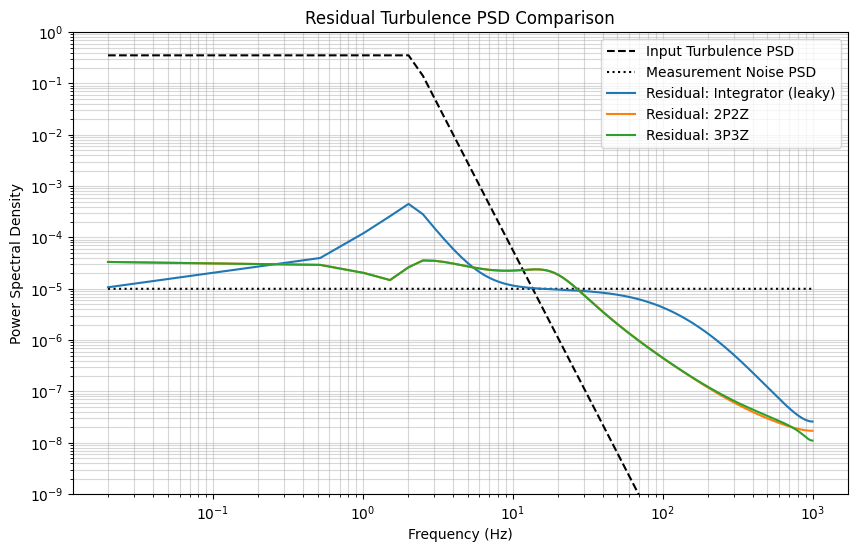

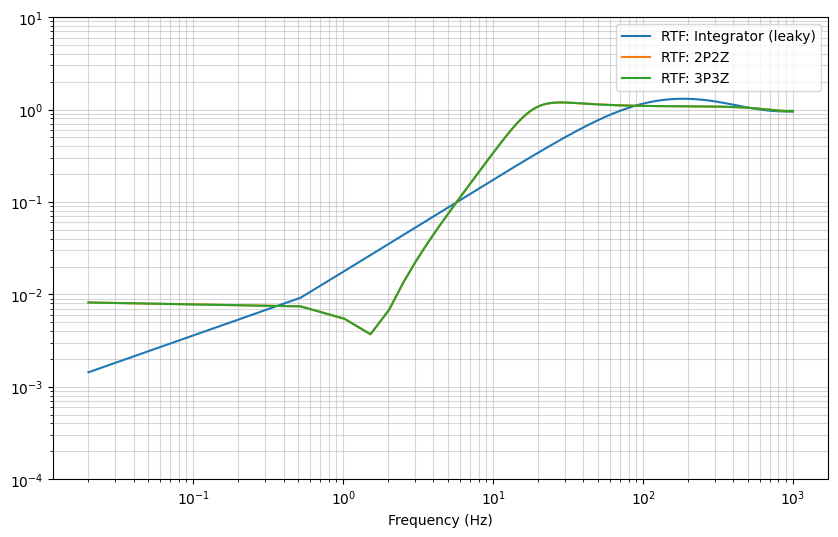

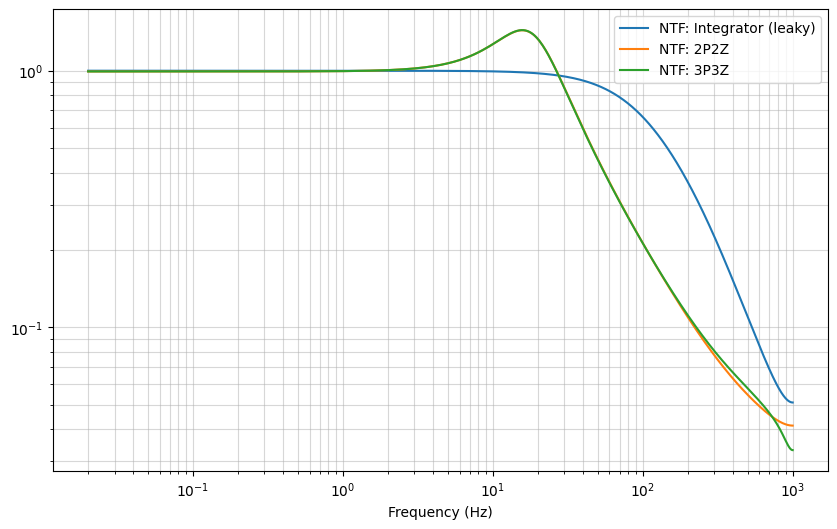

In [2]:
# System Parameters
D = 8.4
V = 20
n = 2

fs = 2000.0 # Sampling frequency (Hz)
N_delay = 2.0 # Pure fractional delay in steps
fc = 0.3*V/D*(n+1) # Turbulence cutoff frequency (Hz)
snr_db = 40.0 # Signal to noise ratio (dB)

# Frequency grid (exclude 0 initially to avoid integrator div-by-zero, handle DC separately)
f = np.linspace(0.02, fs/2, 2000) #np.logspace(-1, np.log10(fs/2), 2000)
snr_linear = 10**(snr_db / 20)

psd_turb, psd_noise = get_psds(f, fc, fs, snr_linear)

print(f"Plant Delay: {N_delay} steps")
print(f"Optimizing for SNR = {snr_db} dB...\n")

# Define candidates: (num_zeros, num_poles, label)
# order is number of poles and zeros
candidates = [
    # (0, 1, "Integrator (standard)"),
    (1, 1, "Integrator (leaky)"),
    # (1, 2, "Double integrator"),
    (2, 2, "2P2Z"),
    # (2, 3, "2P3Z"),
    (3, 3, "3P3Z"),
]

results = {}

for zeros, poles, label in candidates:
    b_opt, a_opt, final_var = optimize_controller(zeros, poles, f, fs, N_delay, psd_turb, psd_noise)
    var_actual, psd_res, rtf_sq, ntf_sq = evaluate_controller(
        np.concatenate((b_opt, a_opt[1:])), 
        zeros, poles, f, fs, N_delay, psd_turb, psd_noise, return_details=True
    )
    results[label] = {
        'variance': var_actual,
        'psd': psd_res,
        'rtf': rtf_sq,
        'ntf': ntf_sq,
        'b': b_opt,
        'a': a_opt
    }
    print(f"{label}:")
    print(f" Numerator (b): {np.round(b_opt, 4)}")
    print(f" Denominator (a): {np.round(a_opt, 4)}")
    print(f" Residual Variance: {var_actual:.4f}\n")

# Plotting
plt.figure(figsize=(10, 6))
plt.loglog(f, psd_turb, 'k--', label='Input Turbulence PSD')
plt.loglog(f, psd_noise, 'k:', label='Measurement Noise PSD')

for label, data in results.items():
    plt.loglog(f, data['psd'], label=f'Residual: {label}')
    
plt.title('Residual Turbulence PSD Comparison')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density')
plt.legend()
plt.ylim([1e-9,1])
plt.grid(True, which='both', ls='-', alpha=0.5)

# Plotting
plt.figure(figsize=(10, 6))
for label, data in results.items():
    plt.loglog(f,np.sqrt(data['rtf']), label=f'RTF: {label}')
plt.xlabel('Frequency (Hz)')
plt.legend()
plt.ylim([1e-4,10])
plt.grid(True, which='both', ls='-', alpha=0.5)

plt.figure(figsize=(10, 6))
for label, data in results.items():
    plt.loglog(f,np.sqrt(data['ntf']), label=f'NTF: {label}')
plt.xlabel('Frequency (Hz)')
plt.legend()
plt.grid(True, which='both', ls='-', alpha=0.5)

In [3]:

import sympy as sp

def scale_iir_cutoff(b_coeffs, a_coeffs, alpha_val):
    """
    Scales the cutoff frequency of an IIR filter of any order.
    
    Parameters:
    b_coeffs: list of numerator coefficients [b0, b1, ..., bN]
    a_coeffs: list of denominator coefficients [a0, a1, ..., aN]
    alpha_val: The transformation parameter (float)
    """
    z_inv = sp.symbols('z_inv')
    alpha = sp.symbols('alpha')
    
    # 1. Define the transfer function H(z) = B(z)/A(z)
    def build_poly(coeffs, var):
        return sum(c * (var**i) for i, c in enumerate(coeffs))
    
    B_z = build_poly(b_coeffs, z_inv)
    A_z = build_poly(a_coeffs, z_inv)
    
    # 2. Define the Lowpass-to-Lowpass transformation: 
    # z^-1 -> (z^-1 - alpha) / (1 - alpha * z^-1)
    transformation = (z_inv - alpha) / (1 - alpha * z_inv)
    
    # 3. Perform the substitution
    B_new = B_z.subs(z_inv, transformation)
    A_new = A_z.subs(z_inv, transformation)
    
    # 4. Simplify to get a standard rational polynomial form
    # We multiply by (1 - alpha*z_inv)**N to clear denominators
    order = max(len(b_coeffs), len(a_coeffs)) - 1
    common_denom = (1 - alpha * z_inv)**order
    
    B_final = sp.simplify(B_new * common_denom)
    A_final = sp.simplify(A_new * common_denom)
    
    # 5. Substitute the numeric alpha and extract coefficients
    B_final_numeric = B_final.subs(alpha, alpha_val).expand()
    A_final_numeric = A_final.subs(alpha, alpha_val).expand()
    
    def extract_coeffs(poly, var, order):
        return [float(poly.coeff(var, i)) for i in range(order + 1)]
    
    new_b = extract_coeffs(B_final_numeric, z_inv, order)
    new_a = extract_coeffs(A_final_numeric, z_inv, order)
    
    # Normalize so a0 = 1.0
    a0 = new_a[0]
    return [b/a0 for b in new_b], [a/a0 for a in new_a]

In [6]:
alpha = lambda x: np.sin(np.pi*V/(fs*D)*(-(x-n)/2)) / np.sin(np.pi*V/(fs*D)*((x+n)/2)) 

# # Substitute z^-1 <- (z^-1 - alpha) / (1 - alpha z^-1)
# def define_new_coeffs(num,den,alpha):
#     new_num = np.zeros(len(num))
#     new_den = np.zeros(len(den))
#     a0,a1,a2 = den
#     b0,b1,b2 = num
#     new_num[0] = 1-alpha*a1+alpha**2*a2
#     new_num[1] = -2*alpha+a1*(1+alpha*+2)+2*a2*alpha
#     new_num[2] = alpha**2-a1*alpha+a2

#     new_den[0] = b0-alpha*b1+alpha**2*b2
#     new_den[1] = -2*b0*alpha+b1*(1+alpha*+2)+2*b2*alpha
#     new_den[2] = alpha**2*b0-b1*alpha+b2

#     return new_num/new_den[0],new_den/new_den[0]

num = np.array([0.1434, 0.0361])#1.0,-1.3,0.3825])
den = np.array([1.0,-0.998])

nn = np.arange(2,30)

L = len(nn)
num_list = np.zeros([L,len(num)])
den_list = np.zeros([L,len(den)])

num_list[0,:] = num
den_list[0,:] = den

# for i in range(1,L):
#     num_list[i,:],den_list[i,:] = define_new_coeffs(num,den,alpha(nn[i]))

# plt.figure()
# for i in range(len(num)):
#     plt.plot(nn, num_list[:,i]-num[i])
# plt.grid()
# plt.title('Numerator progression')

# plt.figure()
# for i in range(len(den)):
#     plt.plot(nn, den_list[:,i]-den[i])
# plt.grid()
# plt.title('Denominator progression')

for i in range(1,L):
    new_num, new_den = scale_iir_cutoff(num,den,alpha(nn[i]))
    num_list[i,:],den_list[i,:] = new_num,new_den #new_num[::-1],new_den[::-1]

# plt.figure()
# for i in range(len(num)):
#     plt.plot(nn, num_list[:,i]-num[i])
# plt.grid()
# plt.title('Numerator progression')

# plt.figure()
# for i in range(len(den)):
#     plt.plot(nn, den_list[:,i]-den[i])
# plt.grid()
# plt.title('Denominator progression')





[0.1434 0.0361] [ 1.    -0.998] 2


(0.1, 1000.0)

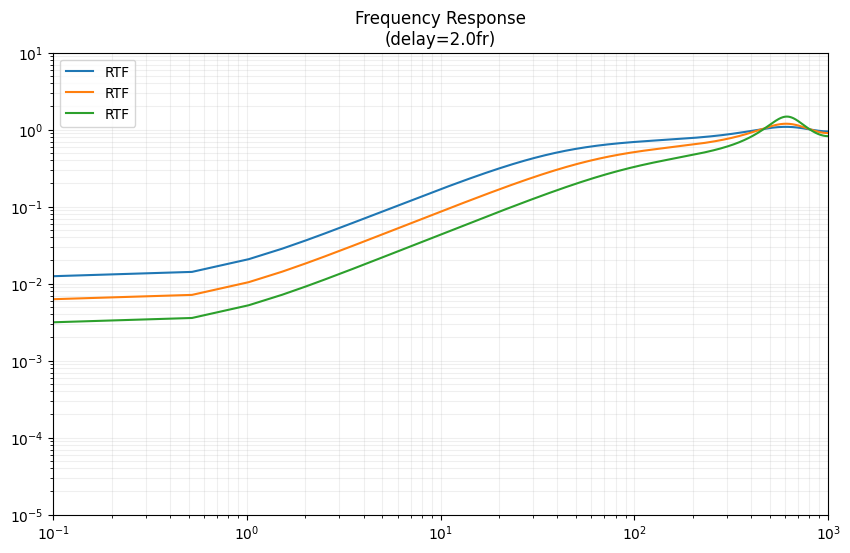

In [8]:
print(num,den,len(num))

filt1 = IirFilterData(ordnum=[len(num)], ordden=[len(den)], num=[num], den=[den])
nw_delay, dw_delay = filt1.discrete_delay_tf(N_delay)
filt3 = IirFilterData(ordnum=[len(num)], ordden=[len(den)], num=[num*2], den=[den])
filt5 = IirFilterData(ordnum=[len(num)], ordden=[len(den)], num=[num*4], den=[den])

rtf1 = filt1.RTF(mode=0,fs=fs,freq=f, dm=1.0, nw=nw_delay, dw=dw_delay, plot=False)
rtf3 = filt3.RTF(mode=0,fs=fs,freq=f, dm=1.0, nw=nw_delay, dw=dw_delay, plot=False)
rtf5 = filt5.RTF(mode=0,fs=fs,freq=f, dm=1.0, nw=nw_delay, dw=dw_delay, plot=False)

plt.figure(figsize=(10, 6))
plt.loglog(f, rtf1, label='RTF')
plt.loglog(f, rtf3, label='RTF')
plt.loglog(f, rtf5, label='RTF')
plt.title(f'Frequency Response\n(delay={N_delay}fr)')
plt.legend(loc='lower left')
plt.grid(True, which="both", alpha=0.2)
plt.legend()
plt.ylim([1e-5,10])
plt.xlim([1e-1,fs/2])